# Stereo using OpenCV

Your name: !double click to enter details!

Your ID number:

In the last assignments, we looked at sparse reconstruction. We extracted a small set of ORB features from the image, we estimated the essential matrix, and we reconstructed the 3D points.

It's quite natural to wonder, though, if we are not dumping too much information when we only take sparse data points. Can we not use all the pixels of the image? Of course, this is where stereo comes in.

In this Notebook, we will take a look at stereo rectification, disparity and depth estimation, using OpenCV.

We are going to use the (relayively) famous [KITTI Vision Benchmark Suite](https://www.cvlibs.net/datasets/kitti/). It's worth heading over to that site to have a look around - loads of nice datasets there. We're just going to take one stereo image pair.

In this activity, I will give you a lot of the code. The OpenCV interfaces can be a bit awkward to use. You will write soem code, and answer lots of questions.

## Read the images and the calibration

Let's start by reading the two images.

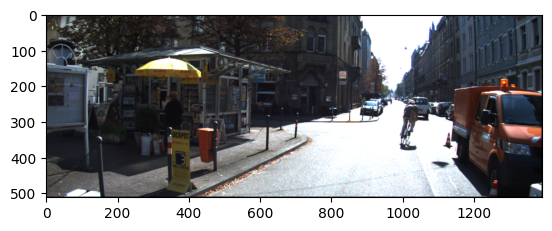

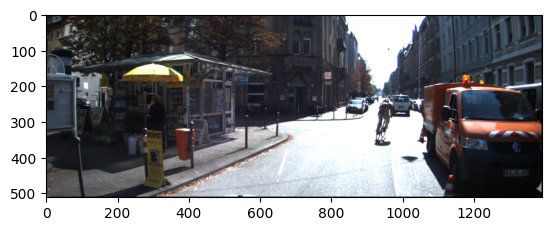

In [3]:
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

# We will read both a colour version and a gray version. The colour version we will use for drawing stuff on,
# and the gray for the processing
imgL_color = cv2.imread('kitti_left_02.png')
imgR_color = cv2.imread('kitti_right_03.png')

imgL_color = cv2.cvtColor(imgL_color, cv2.COLOR_BGR2RGB)
imgR_color = cv2.cvtColor(imgR_color, cv2.COLOR_BGR2RGB)

imgL = cv2.imread('kitti_left_02.png',cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread('kitti_right_03.png',cv2.IMREAD_GRAYSCALE)

plt.figure()
plt.imshow(imgL_color,cmap='gray')
plt.figure()
plt.imshow(imgR_color,cmap='gray')

The KITTI vehicle set up - note the stereo camera rig on top of the vehicle.

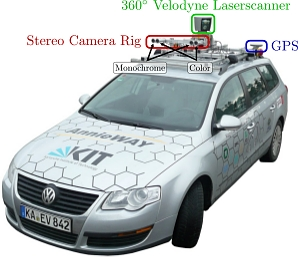

Now let's get the calibration info. This is just extracted from the KITTI datasets.

In [4]:
import numpy as np

# Distortion parameters, per the OpenCV model (this is 3 radial distortion parameters and two tangential distortion parameters)
dist_l = np.array([-3.691481e-01, 1.968681e-01, 1.353473e-03,  5.677587e-04, -6.770705e-02])
dist_r = np.array([-3.639558e-01, 1.788651e-01, 6.029694e-04, -3.922424e-04, -5.382460e-02])

# The instrinsic camera matrices for the two cameras
K_l = np.array([[ 959.791, 0       , 696.0217 ],
                [ 0      , 956.9251, 224.1806 ],
                [ 0      , 0       , 1        ]])                   
K_r = np.array([[ 903.7596, 0       , 695.7519 ],
                [ 0       , 901.9653, 224.2509 ],
                [ 0       , 0       , 1        ]])

# The camera positions are defined in a global reference frame, so they have separate rotation and position
R_l = np.array([[  0.999975800, -0.005267463, -0.004552439 ],
                [  0.005251945,  0.999980400, -0.003413835 ],
                [  0.004570332,  0.003389843,  0.999838000 ]])                   
R_r = np.array([[  0.999559900,  0.016995220, -0.024313130 ],
                [ -0.017044220,  0.999853100, -0.001809756 ],
                [  0.024278800,  0.002223358,  0.999702800 ]])

t_l = np.array([  0.05956621, 0.0002900141,  0.002577209 ])
t_r = np.array([ -0.47310500, 0.0055514700, -0.005250882 ])

# For subsequent processing, we need the RELATIVE positions of the cameras
# R is the orientation of the right camera in the reference frame of the left camera
# And t is the position of the right camera in the reference frame of the left camera
R = R_l.T @ R_r
t = R_l.T @ (t_r - t_l)

# The image shape
h, w = imgL.shape[:2]

## Do the stereo rectification

Now we will use OpenCV to do the rectification. The first step is to define the rectification parameters, i.e. the new camera matrices. It's worth having a look at the `cv2.stereoRectify`

In [5]:
R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(K_l, dist_l, K_r, dist_r, (w, h), R, t, 
                                                  cv2.CALIB_ZERO_DISPARITY, 0, (w, h),alpha=0)

<font color='blue'>

#### Task

Print the camera matrices `P1` and `P2` that are output from the `stereoRectify` function above.

In [6]:
##################################
# Your code here
print("P1:\n ", P1)
print("P2:\n ", P2)

P1:
  [[972.82072754   0.         694.91941071   0.        ]
 [  0.         972.82072754 208.83206558   0.        ]
 [  0.           0.           1.           0.        ]]
P2:
  [[ 972.82072754    0.          694.91941071 -518.27483076]
 [   0.          972.82072754  208.83206558    0.        ]
 [   0.            0.            1.            0.        ]]


<font color='blue'>

#### Questions
    
**Question**: Describe the new projection matrices. What can you say about the intrinsics (particularly, compared to the input intrinsics in `K_l` and `K_r`)? Is there a relative rotation and/or translation between the new projection matrices?

<font color='blue'>

**Question**: Given the projection matrices above, can you estimate the physical distance between the cameras? The final unit would be in metres.

### Now actually rectify the images

Now we will actually transform the images according to the new projection matrices above. That is, we will create the stereo image pair.

In [7]:
# The first step is to create the maps for the rectification. This function returns a
# Look-Up-Table that can be subsequently used to do the mapping to the new image.
map1x, map1y = cv2.initUndistortRectifyMap(K_l, dist_l, R1, P1, (w, h), cv2.CV_32FC1)
map2x, map2y = cv2.initUndistortRectifyMap(K_r, dist_r, R2, P2, (w, h), cv2.CV_32FC1)

# Let's then remap the image. We will do this for both the color and the gray images
imgL_rColor = cv2.remap(imgL_color, map1x, map1y, cv2.INTER_LINEAR)
imgR_rColor = cv2.remap(imgR_color, map2x, map2y, cv2.INTER_LINEAR)
imgL_rGray = cv2.remap(imgL, map1x, map1y, cv2.INTER_LINEAR, cv2.BORDER_ISOLATED)
imgR_rGray = cv2.remap(imgR, map2x, map2y, cv2.INTER_LINEAR, cv2.BORDER_ISOLATED)

<font color='blue'>

#### Task

Plot a set of horizontal lines across both resulting images (`imgL_rColor` and `imgR_rColor`) at the same height. We know that these are now epipolar lines - that is the goal of the rectfication process.

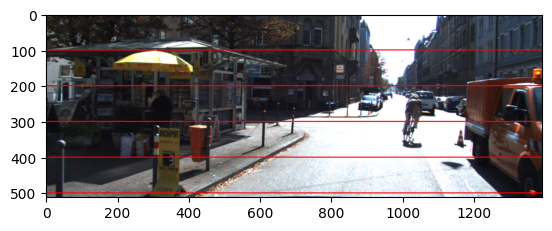

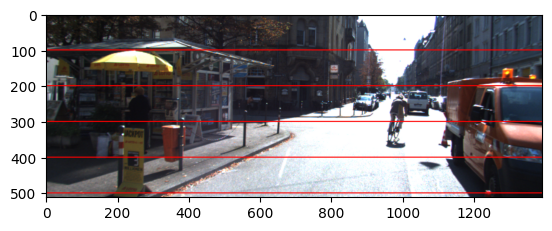

In [8]:
##################################
# Your code here
for i in np.arange(0, h, 100):
    cv2.line(imgL_rColor, (0, i), (w, i), (255, 0, 0), 2)
    cv2.line(imgR_rColor, (0, i), (w, i), (255, 0, 0), 2)


plt.figure()
plt.imshow(imgL_rColor)
plt.figure()
plt.imshow(imgR_rColor)

<font color='blue'>

#### Questions
    
**Question**: Describe what you see with the horizontal lines. Does it look like the stereo rectification did a good job? Explain

Yes, the stereo rectification worked well, we can see that the red lines pass at the same positions on both images, though, some of the field of vision has been removed from the edges.

### Compute the disparity

We will use OpenCV to create the disparity for the image pair.

There are two parameters. `numDisparities` is the maximum disparity size/distance. `blockSize` is the size of the kernel for the stereo block matching.

We have some parameters set below, but this doesn't look great.

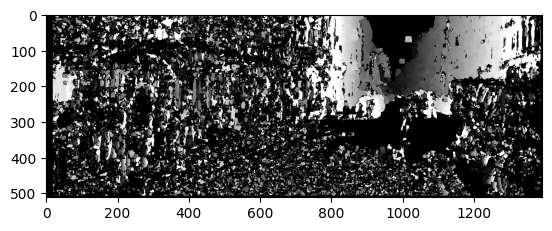

In [13]:
stereo = cv2.StereoBM.create(numDisparities=16, blockSize=9)
disparity = stereo.compute(imgL_rGray, imgR_rGray)
plt.imshow(disparity,'gray')
plt.show()

<font color='blue'>
    
#### Task:
The disparity above is not very good. Copy the code a few times, and play with the parameters to see if you can make it better.

from the openCV documentation the parameters are defined as:

numDisparities	the disparity search range. For each pixel algorithm will find the best disparity from 0 (default minimum disparity) to numDisparities. The search range can then be shifted by changing the minimum disparity.


blockSize	the linear size of the blocks compared by the algorithm. The size should be odd (as the block is centered at the current pixel). Larger block size implies smoother, though less accurate disparity map. Smaller block size gives more detailed disparity map, but there is higher chance for algorithm to find a wrong correspondence.

here I create a loop to check the effect of changing the params when computing disparity

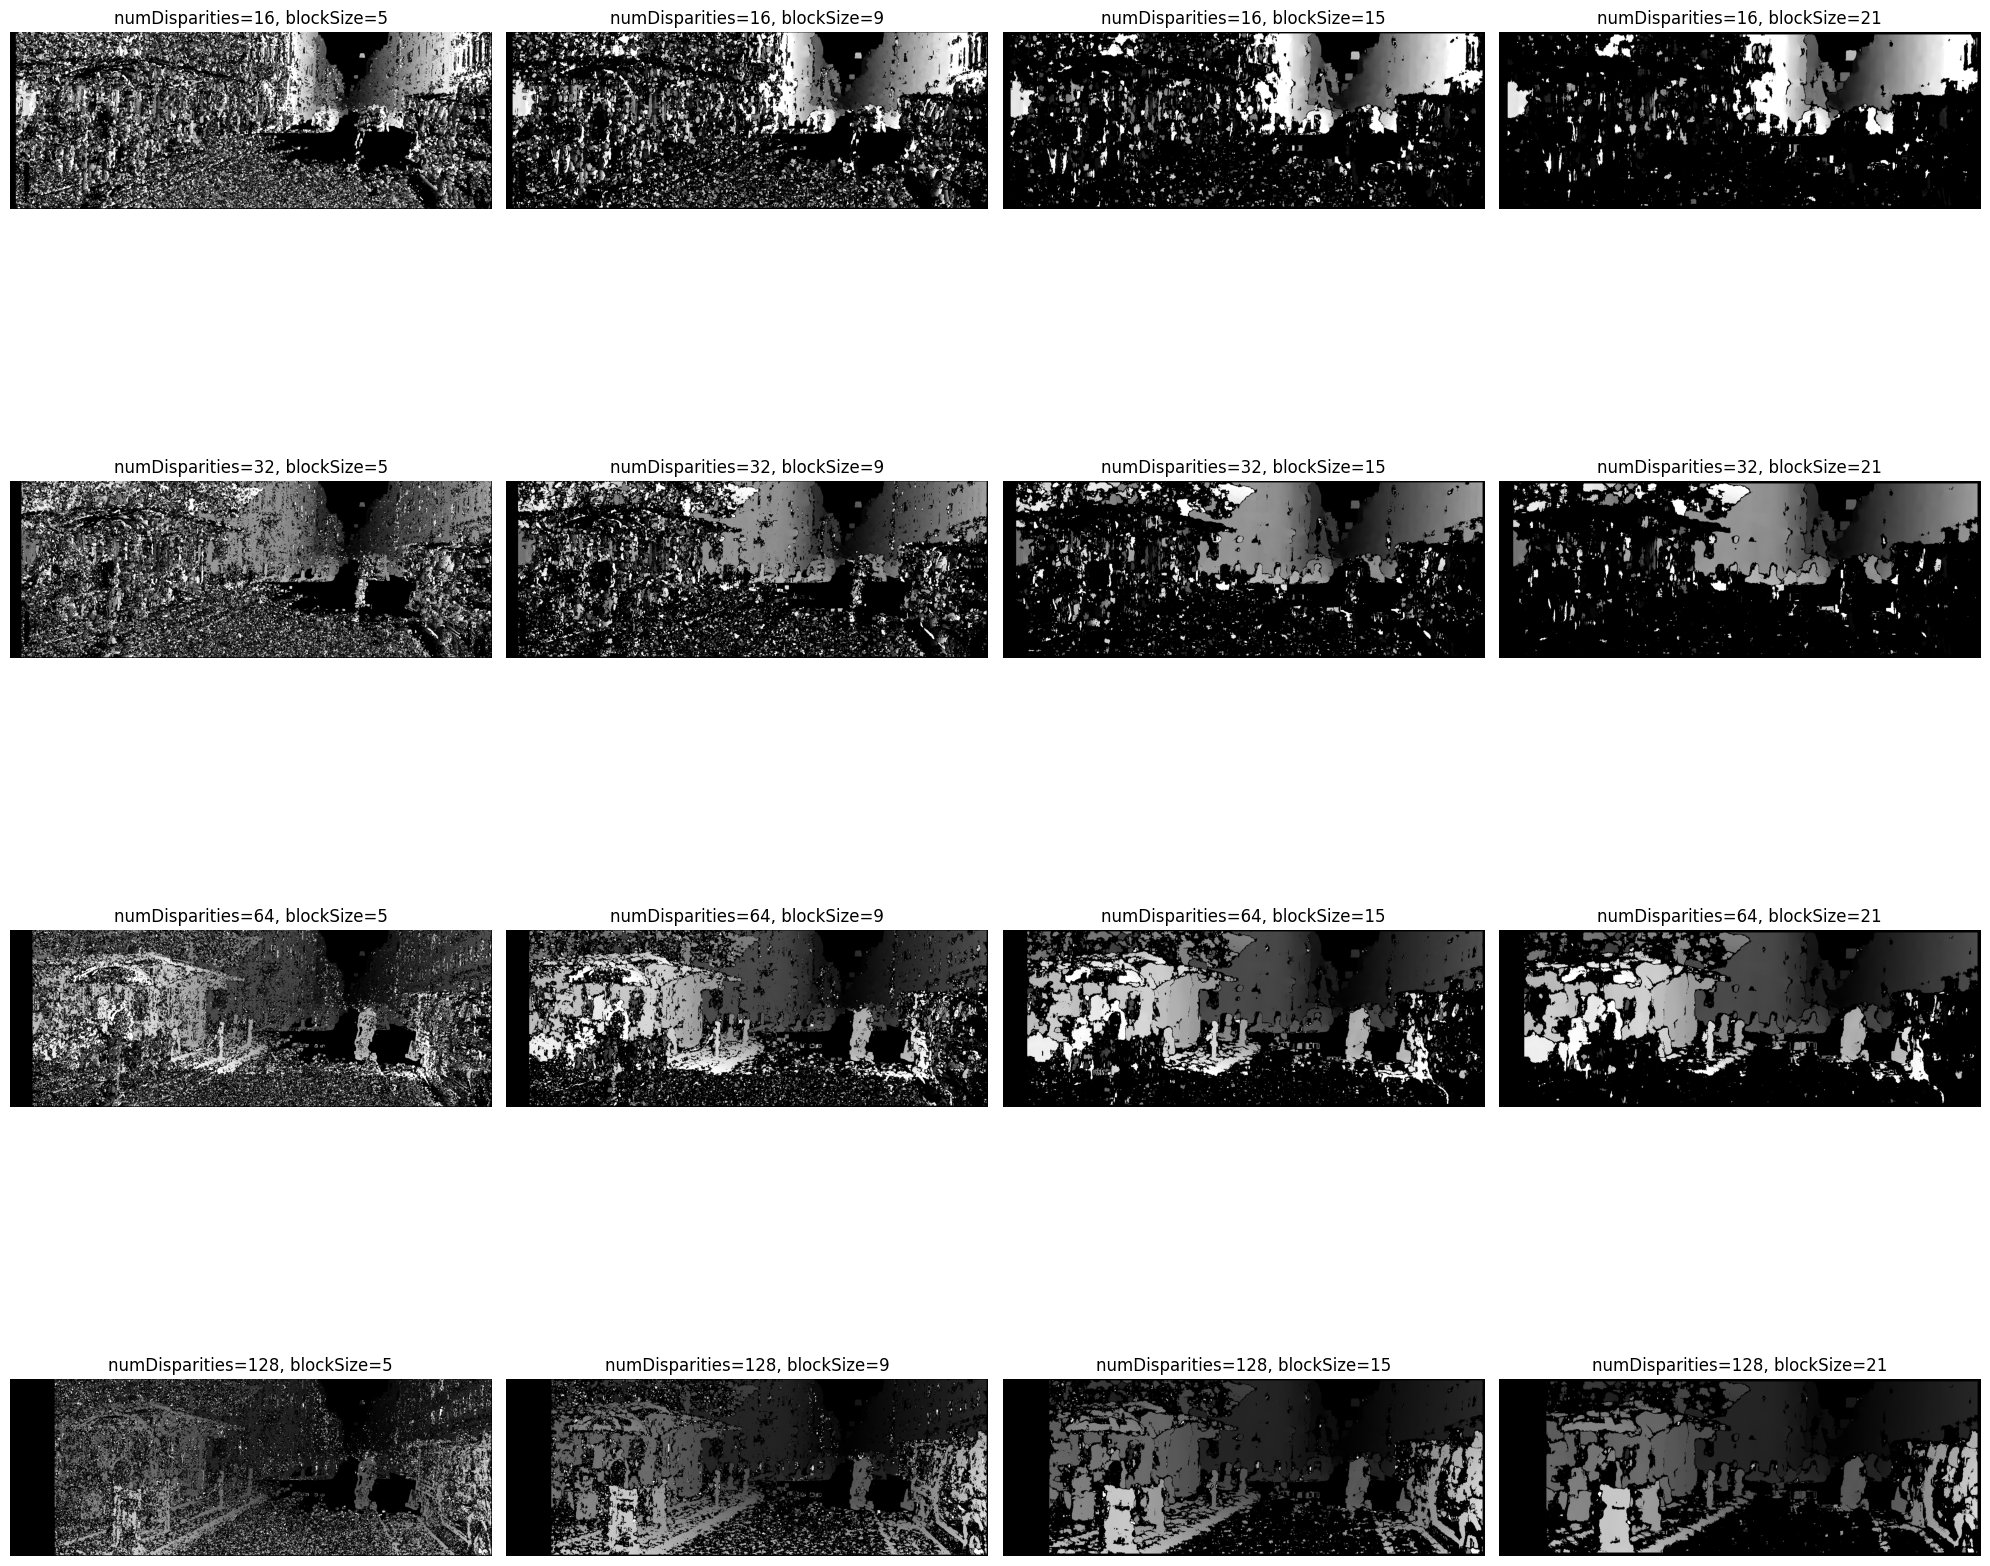

In [14]:
num_disparities = [16, 32, 64, 128]
block_sizes = [5, 9, 15, 21]

fig, axes = plt.subplots(len(num_disparities), len(block_sizes), figsize=(20, 20))

for i, num_disp in enumerate(num_disparities):
    for j, block_size in enumerate(block_sizes):
        stereo = cv2.StereoBM.create(numDisparities=num_disp, blockSize=block_size)
        disparity = stereo.compute(imgL_rGray, imgR_rGray)
        
        ax = axes[i, j]
        ax.imshow(disparity, 'gray')
        ax.set_title(f'numDisparities={num_disp}, blockSize={block_size}')
        ax.axis('off')

plt.tight_layout()
plt.show()

<font color='blue'>

# Questions

<font color='blue'>

**Question**: We started with numDisparities equal to 16. It seems that only the distant parts of the scene are detected well. Why is this?

<font color='blue'>

**Question**: What configuration did you 'land on' that looked good? Can you explain the choice of parameters?

<font color='blue'>

**Question**: In the stereo disparity image, the road is not well detected, regardless of blockSize or numDisparities setting. Explain this.

<font color='blue'>

**Question**: If we display the disparity using the cmap='gray' option, then the disparity is displayed in grayscale. Larger distances in the image are brighter. Explain why it seems that closer objects are brighter.

<font color='blue'>

**Question**: Play around with the `blockSize` parameter, making it smaller and larger. What impact does it seem to have? Describe the tradeoff.